In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add dirctory with model moduels to path
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form.
The demand vector is generated with demand for cattle meat, pig meat and cattle milk equal to what is in the agricultural statistics.

In [7]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

In [8]:
# Create demand vectors
# Animal products
D_ani = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21) * 1000000,
        ('organic','cattle','meat')      : 21 * 1000000,
        ('conventional','cattle','milk') : (2760-464) * 1000000,
        ('organic','cattle','milk')      : 464 * 1000000,
        ('conventional','pigs','meat')   : (249-6) * 1000000,
        ('organic','pigs','meat')        : 6 * 1000000,
    },
)
D_ani.index.rename(['prod_system','species','product'], inplace=True)

# Crop products (kg DM)
D_crp = pd.Series(
    {
        ('conventional','wheat')         :0,
        ('organic','wheat')              :0,
    },
)
D_crp.index.rename(['prod_system','crop_product'], inplace=True)

D = {'ani':D_ani, 'crp':D_crp}

# Run test scenario 'baseline'
This test scenario includes a 6% increase in milk yield per cow (parameter='milk_prod') per every 5 years and a yield increase of 20% from 2020 to 2050 (parameter='yield').

The scenario is defined in the different parameter Excel files in 'data/production_parameters' under the sheets named 'scn_baseline'

A lot of warnings are generated because the ParameterRetriever returns NaN for some parameters. This is not a problem at the moment but I kept the warnings to make sure that we find a good way to treat missing parameter values. Right now these are genreally replaced by zero in the code but this is maybee not a great idea.

## Run model

In [9]:
tic = time.time()

# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','CropProduction.xlsx')
    ),
    index = x0_crp.index
)    

# Instantiate animal herds
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        herds[(sp,br,ps,'none')] = \
            cm.CattleHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','PigHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            ) 

# Instantiate manure management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','FeedMgmt.xlsx')
    )
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','ManureMgmt.xlsx')
    )
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(D,x0,crops,herds,feed_mgmt)


# Define years and create output container
years = ['2020','2030','2040','2050']
scn = 'Dairy yield'
output = pd.DataFrame(
    columns=['crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':scn,'year':years}))
)

# Loop through years
for year in years:
    print(year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values('baseline',year)

    # Calculate crops
    crops.calculate(
        verbose = True
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose = True)

    # Calculate feed
    feed_mgmt.calculate(verbose=True)    

    # Calculate manure
    manure_mgmt.calculate(verbose=True)

    # Distribute animals and crops
    geodist.make_and_solve(use_cons=[1,2,3,4],verbose=True)


    # Scale and append results
    output.loc[(scn,year),'crp'] = crops.scale(geodist.x['crp'])
    
    output.loc[(scn,year),'ani'] = concat_herds([
        h.scale(
            geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
            x_is = h.x_is
        )
        for h in herds
    ])

print(f'Done! Elapsed time: {(time.time()-tic):.0f} sec')

2020


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\PigHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\ManureMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No 

[11:43:10][CropProduction] Calculating harvest ...
[11:43:10][CropProduction] Calculating production ...
[11:43:10][CropProduction] Done! Elapsed time: 0 sec
[11:43:10][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:43:11][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:43:11][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:43:11][AnimalHerd (cattle, beef, organic, none)] Calculating herd structure ...
[11:43:11][AnimalHerd (cattle, beef, organic, none)] Calculating production ...
[11:43:11][AnimalHerd (cattle, beef, organic, none)] Done! Elapsed time: 1 sec
[11:43:11][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[11:43:12][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[11:43:12][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 0 sec
[11:43:12][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = conventional
f_animal = piglets
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = conventional
f_animal = gilts
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' match

[11:43:13][AnimalHerd (pigs, none, organic, none)] Calculating production ...
[11:43:13][AnimalHerd (pigs, none, organic, none)] Done! Elapsed time: 0 sec
[11:43:13][FeedMgmt] Calculating feed consumption ...


...

[11:47:21][CropProduction] Calculating harvest ...
[11:47:21][CropProduction] Calculating production ...
[11:47:22][CropProduction] Done! Elapsed time: 0 sec
[11:47:22][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:47:22][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:47:22][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:47:22][AnimalHerd (cattle, beef, organic, none)] Calculating herd structure ...
[11:47:22][AnimalHerd (cattle, beef, organic, none)] Calculating production ...
[11:47:23][AnimalHerd (cattle, beef, organic, none)] Done! Elapsed time: 1 sec
[11:47:23][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[11:47:23][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[11:47:23][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 0 sec
[11:47:23][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = conventional
f_animal = piglets
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = conventional
f_animal = gilts
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' match

[11:47:24][AnimalHerd (pigs, none, organic, none)] Calculating production ...
[11:47:24][AnimalHerd (pigs, none, organic, none)] Done! Elapsed time: 0 sec
[11:47:24][FeedMgmt] Calculating feed consumption ...


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = organic
f_animal = growing pigs
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'live_weight' found in '..\data\prod_parameters\CattleHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_breed = beef
f_prod_system = conventional
f_sub_system = none
f_animal = breeding bulls
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'live_weight' found in '..\dat

[11:47:28][FeedMgmt] Calculating demand for crop products ...
[11:47:30][FeedMgmt] Calculating demand for by-products ...
[11:47:30][FeedMgmt] Done! Elapsed time: 6 sec
[11:47:30][ManureMgmt] Calculating N excretion ...
[11:47:31][ManureMgmt] Calculating N losses ...
[11:47:36][ManureMgmt] Calculating N available to spread ...
[11:47:36][ManureMgmt] Done! Elapsed time: 6 sec
[11:47:36][GeoDist] Making constraint C1 ...
[11:47:38][GeoDist] Making constraint C2 ...
[11:48:33][GeoDist] Making constraint C3 ...
[11:48:33][GeoDist] Making constraint C4 ...
[11:48:33][GeoDist] Making objective O1 ...
[11:48:33][GeoDist] Defining problem ...
[11:48:33][GeoDist] Finding solution ...
[11:48:52][GeoDist] Optimal solution found! Status: 'optimal', Solver: 'OSQP'
[11:48:52][GeoDist] Done! Elapsed time: 76 sec
Done! Elapsed time: 347 sec


## Plot output

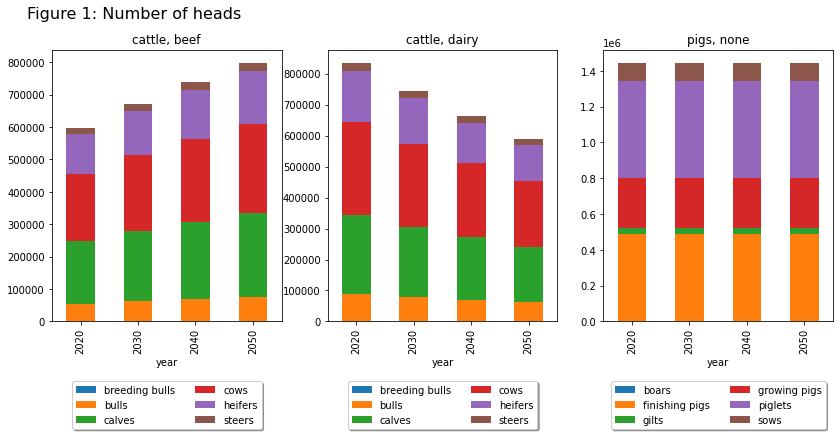

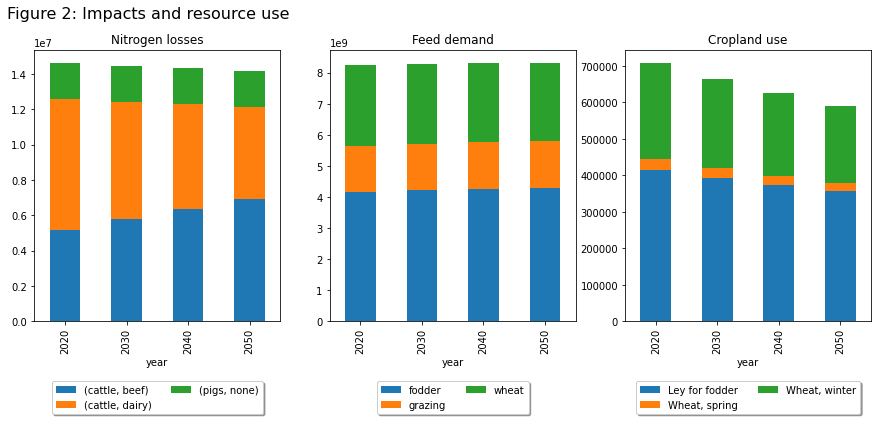

In [10]:
## FIGURE 1 --------------------->

# Number of animal heads
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].heads.groupby(['species','breed','animal'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

idxs = plot_data.columns.droplevel('animal').unique()

fig, axs = plt.subplots(1,len(idxs), figsize=(14,5))
n = 0

for idx in idxs:
    
    ax=axs[n]
    
    (
        plot_data.xs(idx,level=['species','breed'],axis=1).
        reset_index().plot.bar(x='year', ax = ax, stacked=True)
    )
    
    ax.set_title(', '.join(idx),color='black')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
          ncol=2, fancybox=True, shadow=True)
    
    n += 1
        
plt.suptitle('Figure 1: Number of heads', fontsize=16, x=0.1, y=1, horizontalalignment='left')
plt.show()

## FIGURE 2 --------------------->
# N losses

plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].manure.N_loss.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

fig, axs = plt.subplots(1,3, figsize=(15,5))

(
    plot_data.reset_index()
    .plot.bar(x='year', ax = axs[0], stacked=True)
)

axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
      ncol=2, fancybox=True, shadow=True)
        
axs[0].set_title('Nitrogen losses')

# Feed demand

plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].feed.crop_product_demand.groupby(['crop_prod'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

(
    plot_data.reset_index()
    .plot.bar(x='year', ax = axs[1], stacked=True)
)

axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
      ncol=2, fancybox=True, shadow=True)

axs[1].set_title('Feed demand')

# Cropland use

sel=['Wheat, winter','Wheat, spring','Ley for fodder']

idx = pd.IndexSlice

plot_data = pd.concat([
    output.loc[(scn,y),'crp'].area.loc[idx[sel]].groupby('crop').sum()
    for y in years
], axis=1).T
plot_data.index = pd.Index(years,name='year')
(
    plot_data.reset_index()
    .plot.bar(x='year', ax = axs[2], stacked=True)
)

axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
      ncol=2, fancybox=True, shadow=True)

axs[2].set_title('Cropland use')

plt.suptitle('Figure 2: Impacts and resource use', fontsize=16, x=0.1, y=1, horizontalalignment='left')
plt.show()